# **Módulo 3: Visualización de datos interactivos**

## **Tratamiento de datos faltantes y atípicos**

In [6]:
import pandas as pd
import numpy as np

# Cargar el archivo CSV proporcionado
#filename = 'https://raw.githubusercontent.com/cdeoroaguado/Datos/refs/heads/main/dataviz/ds_salaries.csv'
filename = "_data/ds_salaries.csv"
df =  pd.read_csv(filename)

In [7]:
# Informacion del dataset
df.head()

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
0,2020.0,Data Scientist,Mid,FT,DE,L,0,76227.0
1,2020.0,Machine Learning Scientist,Senior,FT,JP,S,0,248257.0
2,2020.0,Big Data Engineer,Senior,FT,GB,M,50,104100.0
3,2020.0,Product Data Analyst,Mid,FT,HN,S,0,19097.0
4,2020.0,Machine Learning Engineer,Senior,FT,US,L,50,143225.0


In [ ]:
# Copia del dataset
df_va = df.copy()

# Revisar los datos faltantes en el conjunto de datos
missing_values = df_va.isnull().sum()

# Calcular el porcentaje de valores faltantes
missing_percentage = (missing_values / len(df_va)) * 100

# Crear un DataFrame con el análisis de datos faltantes
missing_data = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Porcentaje Faltante (%)': missing_percentage
})

missing_data

## Como la suma da menos del 5% de los datos, se puede eliminar las filas con valores faltantes


,Valores Faltantes,Porcentaje Faltante (%)
Working_Year,12,1.976936
Designation,7,1.153213
Experience,0,0.000000
Employment_Status,0,0.000000
Employee_Location,0,0.000000
Company_Size,0,0.000000
Remote_Working_Ratio,0,0.000000
Salary_USD,10,1.647446


#### **Eliminación de datos faltantes** 

In [9]:
# Coloquemos un umbral
umbral = len(df_va) * 0.05  # 5% del total de filas

# Selecciona columnas con valores faltantes <= umbral
cols_to_drop = df_va .columns[missing_values <= umbral]

# Elimina filas con valores faltantes en las columnas seleccionadas
df_va.dropna(subset=cols_to_drop, inplace=True)

In [10]:
# informacion del dataset ajustado
df_va.info()

<class 'pandas.core.frame.DataFrame'>
Index: 578 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          578 non-null    float64
 1   Designation           578 non-null    object 
 2   Experience            578 non-null    object 
 3   Employment_Status     578 non-null    object 
 4   Employee_Location     578 non-null    object 
 5   Company_Size          578 non-null    object 
 6   Remote_Working_Ratio  578 non-null    int64  
 7   Salary_USD            578 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 40.6+ KB


In [11]:
# Revisar los datos faltantes en el conjunto de datos
missing_values = df_va.isnull().sum()

# Calcular el porcentaje de valores faltantes
missing_percentage = (missing_values / len(df_va)) * 100

# Crear un DataFrame con el análisis de datos faltantes
missing_data = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Porcentaje Faltante (%)': missing_percentage
})

missing_data

,Valores Faltantes,Porcentaje Faltante (%)
Working_Year,0,0.0
Designation,0,0.0
Experience,0,0.0
Employment_Status,0,0.0
Employee_Location,0,0.0
Company_Size,0,0.0
Remote_Working_Ratio,0,0.0
Salary_USD,0,0.0


Otra forma para eliminar los datos faltantes es:

In [14]:
# copia del dataset
df_2 = df.copy()

# eliminar las filas con Nans
df_clean =  df_2.dropna()

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 578 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          578 non-null    float64
 1   Designation           578 non-null    object 
 2   Experience            578 non-null    object 
 3   Employment_Status     578 non-null    object 
 4   Employee_Location     578 non-null    object 
 5   Company_Size          578 non-null    object 
 6   Remote_Working_Ratio  578 non-null    int64  
 7   Salary_USD            578 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 40.6+ KB


In [ ]:
# Revisar los datos faltantes en el conjunto de datos
missing_values = # TU CODIGO AQUI

# Calcular el porcentaje de valores faltantes

missing_percentage = # TU CODIGO AQUI
# Crear un DataFrame con el análisis de datos faltantes
missing_data = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Porcentaje Faltante (%)': missing_percentage
})

missing_data

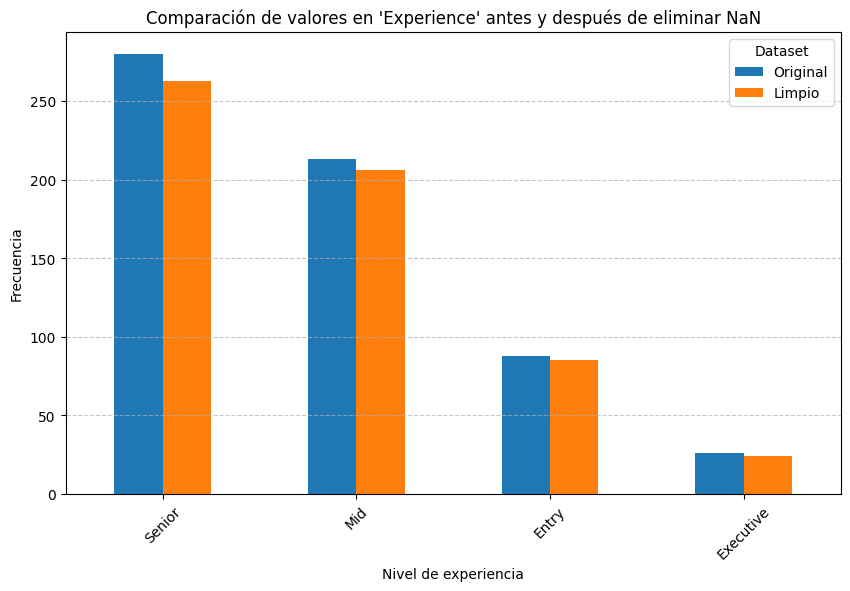

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Contar frecuencias en cada DataFrame
original_counts = df['Experience'].value_counts()
clean_counts = df_clean['Experience'].value_counts()

# Unir ambos conteos en un solo DataFrame
comparison = pd.concat(
    [original_counts.rename("Original"), clean_counts.rename("Limpio")],
    axis=1
).fillna(0)

# Crear gráfico de barras agrupado
comparison.plot(kind='bar', figsize=(10, 6))

plt.title("Comparación de valores en 'Experience' antes y después de eliminar NaN")
plt.xlabel("Nivel de experiencia")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [16]:
from scipy.stats import chi2_contingency

# Alinear categorías para evitar errores
comparison_table = pd.concat([original_counts, clean_counts], axis=1, keys=['Original', 'Limpio']).fillna(0)

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(comparison_table.T)

# Mostrar resultados
print("Prueba Chi-cuadrado de homogeneidad")
print("Estadístico chi²:", chi2)
print("Grados de libertad:", dof)
print("Valor p:", p)

Prueba Chi-cuadrado de homogeneidad
Estadístico chi²: 0.07153479107112373
Grados de libertad: 3
Valor p: 0.9950192620159025


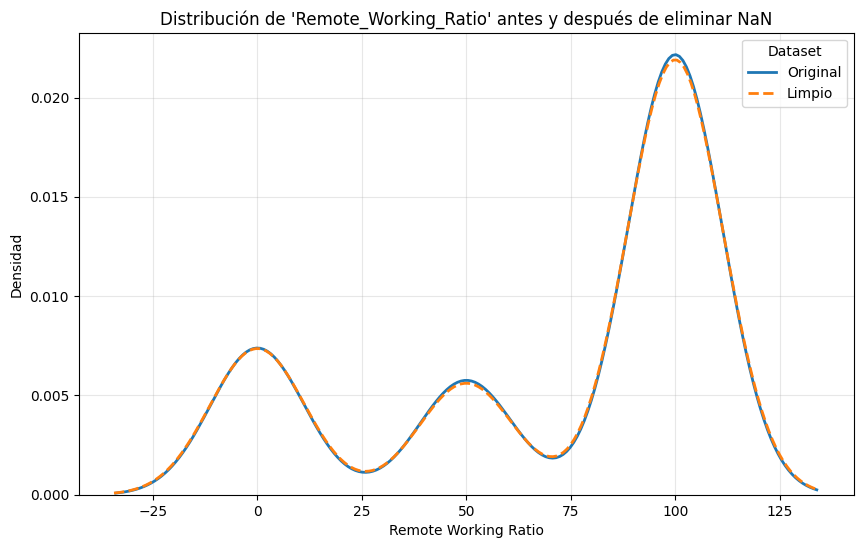

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorar warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Crear gráfico de densidad
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Remote_Working_Ratio'], label='Original', linewidth=2)
sns.kdeplot(df_clean['Remote_Working_Ratio'], label='Limpio', linewidth=2, linestyle='--')

plt.title("Distribución de 'Remote_Working_Ratio' antes y después de eliminar NaN")
plt.xlabel("Remote Working Ratio")
plt.ylabel("Densidad")
plt.legend(title="Dataset")
plt.grid(alpha=0.3)
plt.show()

In [19]:
# PRUEBA KS
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(df['Remote_Working_Ratio'], df_clean['Remote_Working_Ratio'])

print("Prueba Kolmogorov-Smirnov (KS) para 'Remote_Working_Ratio' ")
print("Estadístico KS:", stat)
print("Valor p:", p_value)
if p_value < 0.05:
    print("✅ Hay diferencias significativas entre las dos distribuciones.")
else:
    print("❌ No hay evidencia significativa de que las distribuciones sean diferentes.")

Prueba Kolmogorov-Smirnov (KS) para 'Remote_Working_Ratio' 
Estadístico KS: 0.0018469641951169458
Valor p: 1.0
❌ No hay evidencia significativa de que las distribuciones sean diferentes.


#### **Imputación de datos faltantes**

##### **Datos categóricos**

1. Usando la **moda**:

In [ ]:
# Copia del dataset
df_3 = df.copy()

# Iterar sobre cada columna del DataFrame
for col in df_3.columns:
    # Comprobar si la columna es de tipo objeto (categórica)
    if  df_3[col].dtypes=='object':
        # Imputar los valores faltantes con la moda (categoría más frecuente)
        # TU CODIGO AQUI

2. Usando **Asignación aleatoria**:

In [33]:
# Copia del dataset
df_4 = df.copy()

# Iterar sobre cada columna de df_4
for col in df_4.columns:
    # Comprobar si la columna es de tipo objeto (categórica)
    if df_4[col].dtypes == 'object':
        # Obtener las categorías no faltantes de la columna
        categorias_no_nan =  df_4[col].dropna().unique()
        # Reemplazar valores faltantes con una categoría seleccionada aleatoriamente
        df_4[col] = df_4[col].apply(lambda x: np.random.choice(categorias_no_nan) if pd.isna(x) else x)


##### **Datos numéricos**

1. Usando **la media o el promedio**

In [ ]:
# Copia del dataset
df_6 = df_4.copy()

# Imputar los valores perdidos con imputación de medias
# TU CODIGO AQUI

2. Usando **la mediana**

In [ ]:
# Copia del dataset
df_7 = df_4.copy()

# Imputar los valores perdidos con imputación de medias
# TU CODIGO AQUI

Otra manera adecuada de imputar valores ausentes es mediante la clase `SimpleImputer` de `scikit-learn`


In [ ]:
# Libreria
from sklearn.impute import SimpleImputer

# Copia del dataset
df_8 = df.copy()

# Crear la instancia para imputar con la media
imputer =  # TU CODIGO AQUI

# Imputar los valores faltantes
df_8[['Working_Year','Salary_USD']] = imputer.fit_transform(df_8[['Working_Year','Salary_USD']])

### **Tratamiento de datos atípicos** 

Vamos a crear un gráfico de caja para comprobar si nuestro conjunto de datos contiene valores atípicos. Vamos a utilizar el conjunto de datos `gym.csv`, que contiene información sobre los clientes de un determinado gimnasio.

In [55]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import plotly.express as px

Guarda el archivo `gym.csv` en un DataFrame llamado `gym`, e imprime las cinco primeras filas del mismo para ver cómo son los datos

In [ ]:
gym = # TU CODIGO AQUI
gym.head()

Como puede ver, nuestros datos tienen tres columnas: `age`, `weight`, `sex`. La columna sexo consta de tres valores discretos que corresponden a tres clases discretas: `0 es hombre`, `1 es mujer` y `2 es otro`.

Cree un gráfico de caja con el eje $x$ como columna de sexo y el eje $y$ como peso:

In [57]:
# Importar plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Configurar el renderizador para notebook o Jupyter Book
pio.renderers.default = 'notebook'

In [ ]:
fig = # TU CODIGO AQUI
fig.show()

#### **Tratamiento**

##### **Eliminación de datos atípicos**

Eliminaremos el dato que contiene el valor atípico del conjunto de datos utilizado previamente y, a continuación, visualizaremos el nuevo conjunto de datos mediante un gráfico de caja actualizado.

In [ ]:
# informacion
# TU CODIGO AQUI

Modificar el DataFrame del gimnasio para que solo esté formado por los casos *en los que el peso sea inferior a 104* e imprimir las cinco primeras filas:

In [ ]:
gym_clean =  # TU CODIGO AQUI
gym_clean.head()

Vamos a crear un boxplot para ver el aspecto de los datos

In [ ]:
# Crear el diagrama de violín
fig = # TU CODIGO AQUI

# Configurar fondo blanco y rejilla gris
fig.update_layout(
    paper_bgcolor='white',  # Fondo del gráfico
    plot_bgcolor='white',   # Fondo de la parte de trazado
    # xaxis=dict(showgrid=True, gridcolor='lightgrey'),  # Rejilla gris en el eje x
    yaxis=dict(showgrid=True, gridcolor='lightgrey')   # Rejilla gris en el eje y
)

# Actualizar el color de la caja a rojo y agregar línea del promedio más gruesa
fig.update_traces(
    box=dict(line_color='red'),     # Color de la caja (rojo)
    meanline_visible=True,          # Mostrar línea del promedio
    meanline=dict(color='darkgreen', width=3)  # Línea del promedio más gruesa y en rojo
)

# Mostrar el gráfico
fig.show()


### **Aplicación de `IterativeImputer`**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
url = # TU CODIGO AQUI
df = pd.read_csv(url, header=None, na_values='?')

In [ ]:
# muestra las primeras filas del dataset
# TU CODIGO AQUI

# Dame la información del dataset
# TU CODIGO AQUI

# Realiza un descriptivo de las variables
# TU CODIGO AQUI

In [ ]:
# Revisar los datos faltantes en el conjunto de datos
missing_values = # TU CODIGO AQUI

# Calcular el porcentaje de valores faltantes
missing_percentage = # TU CODIGO AQUI

# Crear un DataFrame con el análisis de datos faltantes
missing_data = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Porcentaje Faltante (%)': missing_percentage
})

missing_data

In [ ]:
from numpy import isnan
from pandas import read_csv
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [ ]:
data = df.values
ix = [i for i in range(data.shape[1]) if i != 23]
X, y = # TU CODIGO AQUI

print('Missing: %d' % sum(isnan(X).flatten()))

In [ ]:
imputer = # TU CODIGO AQUI
# TU CODIGO AQUI
Xtrans = # TU CODIGO AQUI

print('Missing: %d' % sum(isnan(Xtrans).flatten()))